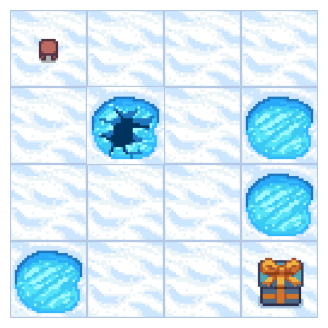

Failed to create secure directory (/run/user/99890/pulse): No such file or directory
ALSA lib dlmisc.c:339:(snd_dlobj_cache_get0) [error.core] Cannot open shared library libasound_module_pcm_pipewire.so (/home/ruiqliu/conda/envs/SML/lib/alsa-lib/libasound_module_pcm_pipewire.so: cannot open shared object file: No such file or directory)


Episode 1/5 finished. total_reward=0.0
Episode 2/5 finished. total_reward=0.0
Episode 3/5 finished. total_reward=0.0
Episode 4/5 finished. total_reward=0.0
Episode 5/5 finished. total_reward=0.0


In [10]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import numpy as np

env = gym.make(
    "FrozenLake-v1",
    desc=None,
    map_name="4x4",
    is_slippery=False,
    success_rate=1.0/3.0,
    reward_schedule=(1, 0, 0),
    render_mode="rgb_array",   # <- key for image frames
)

episodes = 5
delay = 0.1  # seconds between frames


fig, ax = plt.subplots(figsize=(4, 4))
im = None
ax.axis("off")
disp = display(fig, display_id=True)

for ep in range(episodes):
    obs, info = env.reset()
    frame = env.render()
    terminated = truncated = False
    total_reward = 0.0

    while not (terminated or truncated):
        action = env.action_space.sample()  # random action
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        frame = env.render()  # numpy array (H, W, 3)
        if frame is None:
            raise RuntimeError(
                "env.render() returned None. Try installing pygame: `pip install pygame` "
                "and restart the kernel."
            )
        if im is None:
            im = ax.imshow(frame)
        else:
            im.set_data(frame)

        im.set_data(frame)
        disp.update(fig)
        time.sleep(delay)

    print(f"Episode {ep+1}/{episodes} finished. total_reward={total_reward}")

plt.close(fig)
env.close()

In [11]:
# ----------------------------
# Extract MDP (P[s][a] -> list of (p, s', r, done))
# Gymnasium FrozenLake exposes this via env.unwrapped.P
# ----------------------------
P = env.unwrapped.P
nS = env.observation_space.n
nA = env.action_space.n

P[14]

{0: [(1.0, 13, 0, False)],
 1: [(1.0, 14, 0, False)],
 2: [(1.0, 15, 1, True)],
 3: [(1.0, 10, 0, False)]}

In [12]:
# ----------------------------
# Value Iteration
# ----------------------------
def value_iteration(P, nS, nA, gamma=0.99, tol=0, max_iter=1000):
    V = np.zeros(nS, dtype=np.float64)

    for it in range(max_iter):
        delta = 0.0
        V_new = np.empty_like(V)

        for s in range(nS):
            q_sa = np.zeros(nA, dtype=np.float64)
            for a in range(nA):
                for p, s2, r, done in P[s][a]:
                    q_sa[a] += p * (r + gamma * (0.0 if done else V[s2]))
            V_new[s] = np.max(q_sa)
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        if delta < tol:
            break

    # greedy policy
    pi = np.zeros(nS, dtype=np.int64)
    for s in range(nS):
        q_sa = np.zeros(nA, dtype=np.float64)
        for a in range(nA):
            for p, s2, r, done in P[s][a]:
                q_sa[a] += p * (r + gamma * (0.0 if done else V[s2]))
        pi[s] = int(np.argmax(q_sa))

    return V, pi, it + 1

V, pi, iters = value_iteration(P, nS, nA, gamma=0.9)
print(f"Value iteration converged in {iters} iterations.")
print("Policy (0=Left,1=Down,2=Right,3=Up):")
print(pi.reshape(4, 4))

Value iteration converged in 1000 iterations.
Policy (0=Left,1=Down,2=Right,3=Up):
[[1 2 1 0]
 [1 0 1 0]
 [2 1 1 0]
 [0 2 2 0]]


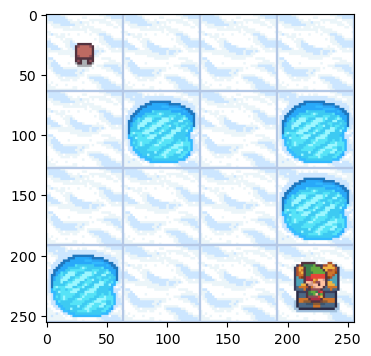

Episode 1/5 finished. total_reward=1.0
Episode 2/5 finished. total_reward=1.0
Episode 3/5 finished. total_reward=1.0
Episode 4/5 finished. total_reward=1.0
Episode 5/5 finished. total_reward=1.0


In [13]:
# -------- Rollout + notebook image rendering (NO clear_output) --------
episodes = 5
delay = 0.15

fig, ax = plt.subplots(figsize=(4, 4))

# initialize one image + persistent display handle (prevents many duplicate images)
obs, info = env.reset()
frame = env.render()
im = ax.imshow(frame)
disp = display(fig, display_id=True)

for ep in range(episodes):
    obs, info = env.reset()
    terminated = truncated = False
    total_reward = 0.0

    while not (terminated or truncated):
        action = pi[obs]  # <-- use value-iteration policy (not random)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        frame = env.render()
        if frame is None:
            raise RuntimeError(
                "env.render() returned None. Try installing pygame: `pip install pygame` "
                "and restart the kernel."
            )

        im.set_data(frame)
        disp.update(fig)
        time.sleep(delay)

    print(f"Episode {ep+1}/{episodes} finished. total_reward={total_reward}")

plt.close(fig)
env.close()